Figuras 7.4, 7.5, 7.6 tomados de: https://www.astroml.org/book_figures/chapter7/index.html

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.decomposition import NMF, FastICA, PCA

from astroML.datasets import sdss_corrected_spectra
from astroML.utils.decorators import pickle_results

In [2]:
if "setup_text_plots" not in globals():
    print('no')
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

no


/Users/jcimental/Documents/Lab_Alma/sklearn-env/lib/python3.9/site-packages/astroML/linear_model/linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


In [3]:
data = sdss_corrected_spectra.fetch_sdss_corrected_spectra()
spectra = sdss_corrected_spectra.reconstruct_spectra(data)
wavelengths = sdss_corrected_spectra.compute_wavelengths(data)

In [19]:
len(spectra)

4000

In [5]:
@pickle_results('spec_decompositions.pkl')    ## Guarda automáticamente resultados en spec_decomposition.pkl'
def compute_PCA_ICA_NMF(n_components):
    spec_mean = spectra.mean(0)

    # PCA: use randomized PCA for speed
    pca = PCA(n_components - 1, random_state=0, svd_solver='randomized')  ## random fija la semilla para tomar 
                                                                           # los mismos espectros
                                                                           # randomized evita diagonalizar la matriz enorme
    pca.fit(spectra)                                                      ## Obtiene los componentes principales
    pca_comp = np.vstack([spec_mean,                                      ## agrega el mean al principio
                          pca.components_])

    # ICA treats sequential observations as related.  Because of this, we need
    # to fit with the transpose of the spectra
    ica = FastICA(n_components - 1, random_state=0)
    ica.fit(spectra.T)                                          ## ICA necesita (gal1(wave1), gal1(wave2), gal1(wave3), ...)
                                                                 #              (gal2(wave1), gal2(wave2), gal2(wave3), ...)
                                                                 #              ( ...            ...           ...         )
                                                                 # es decir (wave, gal) en lugar de (gal, wave)
    ica_comp = np.vstack([spec_mean,
                          ica.transform(spectra.T).T])          ## vuelve al orden (gal, wave)

    # NMF requires all elements of the input to be greater than zero
    spectra[spectra < 0] = 0                                    ## Solo acepta valores positivos del espectro!
    nmf = NMF(n_components, random_state=0)
    nmf.fit(spectra)
    nmf_comp = nmf.components_                                  ## PCA -> data = mean + modos
                                                                 # ICA -> data = mean + independent fluctiations
                                                                 # NMF -> data  = c_i N_i     (no necesita el mean) 
    return pca_comp, ica_comp, nmf_comp

n_components = 5
decompositions = compute_PCA_ICA_NMF(n_components)

@pickle_results: using precomputed results from 'spec_decompositions.pkl'


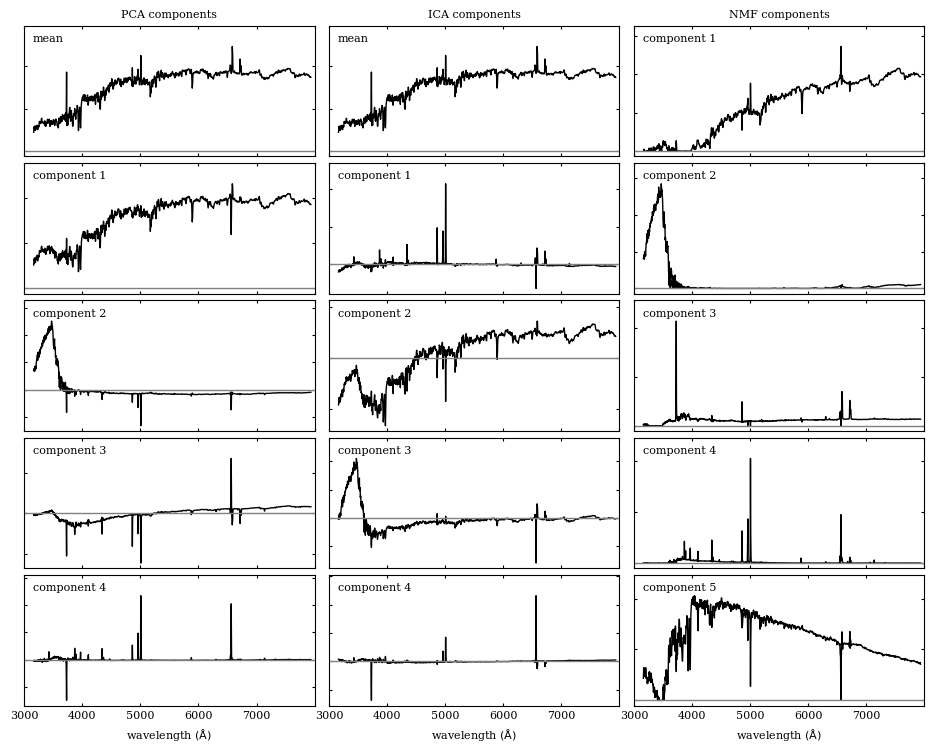

In [6]:
fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(left=0.05, right=0.95, wspace=0.05,
                    bottom=0.1, top=0.95, hspace=0.05)

titles = ['PCA components', 'ICA components', 'NMF components']

for i, comp in enumerate(decompositions):
    for j in range(n_components):
        ax = fig.add_subplot(n_components, 3, 3 * j + 1 + i)

        ax.yaxis.set_major_formatter(plt.NullFormatter())
        ax.xaxis.set_major_locator(plt.MultipleLocator(1000))
        if j < n_components - 1:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        else:
            ax.xaxis.set_major_locator(
                plt.FixedLocator(list(range(3000, 7999, 1000))))
            ax.set_xlabel(r'wavelength ${\rm (\AA)}$')

        ax.plot(wavelengths, comp[j], '-k', lw=1)

        # plot zero line
        xlim = [3000, 8000]
        ax.plot(xlim, [0, 0], '-', c='gray', lw=1)

        if j == 0:
            ax.set_title(titles[i])

        if titles[i].startswith('PCA') or titles[i].startswith('ICA'):
            if j == 0:
                label = 'mean'
            else:
                label = 'component %i' % j
        else:
            label = 'component %i' % (j + 1)

        ax.text(0.03, 0.94, label, transform=ax.transAxes,
                ha='left', va='top')

        for l in ax.get_xticklines() + ax.get_yticklines():
            l.set_markersize(2)

        # adjust y limits
        ylim = plt.ylim()
        dy = 0.05 * (ylim[1] - ylim[0])

        ax.set_ylim(ylim[0] - dy, ylim[1] + 4 * dy)
        ax.set_xlim(xlim)


plt.show()

In [7]:
from astroML import datasets

In [8]:
pca = PCA()
pca.fit(spectra)
evals = pca.explained_variance_ratio_
evals_cs = evals.cumsum()

In [9]:
#  because the spectra have been reconstructed from masked values, this
#  is not exactly correct in this case: we'll use the values computed
#  in the file compute_sdss_pca.py
#evals = data['evals'] ** 2
#evals_cs = evals.cumsum()
#evals_cs /= evals_cs[-1]

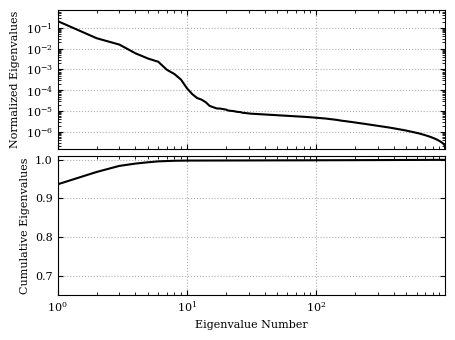

In [18]:
fig = plt.figure(figsize=(5, 3.75))
fig.subplots_adjust(hspace=0.05, bottom=0.12)

ax = fig.add_subplot(211, xscale='log', yscale='log')
ax.grid()
ax.plot(evals, c='k')
ax.set_ylabel('Normalized Eigenvalues')
ax.xaxis.set_major_formatter(plt.NullFormatter())
#ax.set_ylim(5E-4, 100)

ax = fig.add_subplot(212, xscale='log')
ax.grid()
ax.semilogx(evals_cs, color='k')
ax.set_xlabel('Eigenvalue Number')
ax.set_ylabel('Cumulative Eigenvalues')
ax.set_ylim(0.65, 1.01)

plt.show()

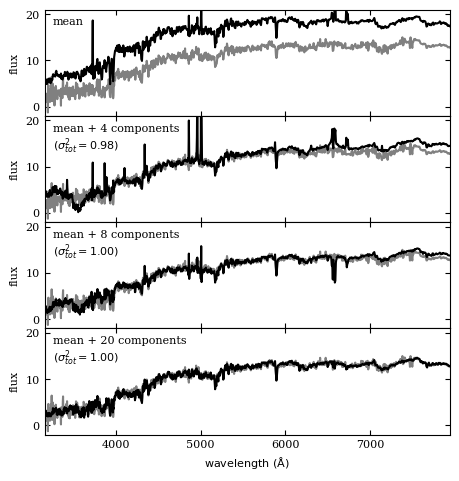

In [20]:
evecs = data['evecs']
spec_mean = spectra.mean(0)

#------------------------------------------------------------
# Find the coefficients of a particular spectrum
spec = spectra[1]
coeff = np.dot(evecs, spec - spec_mean)

#------------------------------------------------------------
# Plot the sequence of reconstructions
fig = plt.figure(figsize=(5, 5))
fig.subplots_adjust(hspace=0, top=0.95, bottom=0.1, left=0.12, right=0.93)

for i, n in enumerate([0, 4, 8, 20]):
    ax = fig.add_subplot(411 + i)
    ax.plot(wavelengths, spec, '-', c='gray')
    ax.plot(wavelengths, spec_mean + np.dot(coeff[:n], evecs[:n]), '-k')

    if i < 3:
        ax.xaxis.set_major_formatter(plt.NullFormatter())

    ax.set_ylim(-2, 21)
    ax.set_ylabel('flux')

    if n == 0:
        text = "mean"
    elif n == 1:
        text = "mean + 1 component\n"
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]
    else:
        text = "mean + %i components\n" % n
        text += r"$(\sigma^2_{tot} = %.2f)$" % evals_cs[n - 1]

    ax.text(0.02, 0.93, text, ha='left', va='top', transform=ax.transAxes)

fig.axes[-1].set_xlabel(r'${\rm wavelength\ (\AA)}$')
plt.show()

In [28]:
list(data.keys())

['norms',
 'spectra',
 'log_OIII_Hb',
 'zerr',
 'mu',
 'coeffs',
 'z',
 'coeff1',
 'lineindex_cln',
 'spec_cln',
 'coeff0',
 'evals',
 'mask',
 'log_NII_Ha',
 'evecs']

In [30]:
help(data)

Help on NpzFile in module numpy.lib.npyio object:

class NpzFile(collections.abc.Mapping)
 |  NpzFile(fid, own_fid=False, allow_pickle=False, pickle_kwargs=None, *, max_header_size=10000)
 |  
 |  NpzFile(fid)
 |  
 |  A dictionary-like object with lazy-loading of files in the zipped
 |  archive provided on construction.
 |  
 |  `NpzFile` is used to load files in the NumPy ``.npz`` data archive
 |  format. It assumes that files in the archive have a ``.npy`` extension,
 |  other files are ignored.
 |  
 |  The arrays and file strings are lazily loaded on either
 |  getitem access using ``obj['key']`` or attribute lookup using
 |  ``obj.f.key``. A list of all files (without ``.npy`` extensions) can
 |  be obtained with ``obj.files`` and the ZipFile object itself using
 |  ``obj.zip``.
 |  
 |  Attributes
 |  ----------
 |  files : list of str
 |      List of all files in the archive with a ``.npy`` extension.
 |  zip : ZipFile instance
 |      The ZipFile object initialized with the zi